## Deep Residual Learning for Multi-Class Distracted Driver Behavior Classification

**This project focuses on classifying distracted driver behaviors from in-vehicle camera images using deep learning.**

**It proposes the development of a robust machine learning model capable of assigning each driver image to one of multiple distinct activity categories, including safe driving, texting, talking on the phone, eating, and other distraction-related behaviors.**

**The main model selected for this study is ResNet-50, a 50-layer deep residual network chosen for its strong performance in complex image-classification tasks and its ability to capture subtle visual patterns through skip connections.**

**The dataset used in this project is a Roboflow Distracted Driver Detection dataset containing 2000 labeled images. The data includes preprocessing such as auto-orientation, and additional steps such as image resizing, normalization, and augmentation will be applied during model training.**

**The expected outcome is a trained multi-class classification model with improved validation and holdout performance after hyperparameter tuning, contributing to safer driver-monitoring systems and road-safety technology.**

## Problem Definition

This project is formulated as a **multi-class image classification problem**, where the goal is to predict the driver’s behavior based on an input image.

Each image is assigned a label corresponding to a specific driving activity. The model must learn to distinguish between safe driving and various forms of distracted behavior.

### Objective

- Build a ResNet-50 model for classification  
- Accurately classify driver behaviors  
- Improve generalization using augmentation and tuning  
- Evaluate performance using accuracy and confusion matrix  

## Data Description

The dataset used in this project is a **Roboflow Distracted Driver Detection dataset** containing approximately **2000 images**.

### Key Characteristics:
- Image-based dataset (RGB images)
- Annotated driver-related behaviors
- Exported in TensorFlow-compatible format
- Preprocessing includes auto-orientation
- No augmentation applied initially

### Planned Preprocessing:
- Resize images to 224×224
- Normalize pixel values
- Apply augmentation (flip, rotation, brightness)
- Split into train, validation, and test sets

In [ ]:
!pip install tensorflow --upgrade

In [21]:
# Core libraries
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.utils import to_categorical

# Sklearn metrics and utilities
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score

# Optional image handling
from PIL import Image

In [22]:
import os
from datetime import datetime
import matplotlib.pyplot as plt

# Create folder once
os.makedirs("figures", exist_ok=True)

def save_fig(name=None):
    """
    Saves the current Matplotlib figure into /figures with:
    - auto timestamp
    - auto name if none provided
    - high DPI
    """
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

    if name is None:
        name = f"figure_{timestamp}"
    else:
        name = f"{name}_{timestamp}"

    path = f"figures/{name}.png"
    plt.savefig(path, dpi=300, bbox_inches='tight')
    print(f"Saved: {path}")

In [23]:
data_dir = "Distracted Driver Detection.v3i.tensorflow"

print("Dataset exists:", os.path.exists(data_dir))
print("Contents:", os.listdir(data_dir))

Dataset exists: True
Contents: ['README.dataset.txt', 'README.roboflow.txt', 'test', 'train', 'valid']


## Dataset Structure Verification

In this step, we verify that the dataset has been correctly loaded and organized into the expected directory structure.

The dataset is expected to be divided into three subsets:
- **Training set (`train`)** – used to train the model  
- **Validation set (`valid`)** – used to tune hyperparameters and monitor performance during training  
- **Test set (`test`)** – used for final evaluation of the model  

The code iterates through each of these subsets and checks:
1. Whether the folder exists  
2. The contents of each folder (e.g., image files and annotation files)

This step is important because it ensures that:
- The dataset path is correctly defined  
- All required data splits are available  
- The data is accessible before proceeding to preprocessing and model training  

By confirming the dataset structure early, we avoid potential errors later in the pipeline.

In [24]:
for split in ["train", "valid", "test"]:
    split_path = os.path.join(data_dir, split)
    print(f"\n--- {split.upper()} ---")
    print("Exists:", os.path.exists(split_path))
    if os.path.exists(split_path):
        print("Contents:", os.listdir(split_path))


--- TRAIN ---
Exists: True
Contents: ['img_0_jpg.rf.03b4da8f7c132930b687121bbd4c9bec.jpg', 'img_0_jpg.rf.508c75b6cac4036262a4cb346ee9a317.jpg', 'img_0_jpg.rf.6e3eca467b0f304c45dc8b9d14a6765d.jpg', 'img_100215_jpg.rf.04c44705607e8d1ebbf11e4aec83cf04.jpg', 'img_100215_jpg.rf.44f151e3704d11bda480e2b1da61e963.jpg', 'img_100299_jpg.rf.39210ae94d7e464baacd39e721a4263d.jpg', 'img_100299_jpg.rf.4a50b7ceb2e51b855afd35255dfbd984.jpg', 'img_100299_jpg.rf.75abccee8ae3131afd2c09d43ab0884b.jpg', 'img_100327_jpg.rf.6d87ec030280ae89c47045478bf6bb18.jpg', 'img_100327_jpg.rf.a0617f7f6ce6aad57a453e2bfaea7a65.jpg', 'img_100334_jpg.rf.e6e259971570c6e868fd9c061b4be400.jpg', 'img_100334_jpg.rf.ffe31bc69587e98fe9dfe3cfd5fdfbc8.jpg', 'img_100368_jpg.rf.9ba0b359c413a7405da270554dddf5fc.jpg', 'img_100368_jpg.rf.d4ab6747931d37e43162561e7d0fe850.jpg', 'img_100368_jpg.rf.d58f38ba203915d93ccfe204248fa12c.jpg', 'img_100379_jpg.rf.7bd1fbcc69c658788a477e8a28cd13cc.jpg', 'img_100394_jpg.rf.0fa9ed9ffa2dae7d453b3a520a126

In [25]:
# Loop through each dataset split: training, validation, and test
for split in ["train", "valid", "test"]:
    
    # Create the full path to the current split directory
    split_path = os.path.join(data_dir, split)
    
    # Print the name of the current split for clarity
    print(f"\n--- {split.upper()} ---")
    
    # Walk through the directory structure
    for root, dirs, files in os.walk(split_path):
        
        # Print the current directory path
        print("ROOT:", root)
        
        # Print the first few subdirectories (if any)
        print("DIRS:", dirs[:5])
        
        # Print the first few files in the directory
        print("FILES:", files[:5])
        
        # Separator for better readability
        print("-" * 40)
        
        # Break after the first iteration to avoid deep traversal
        # (we only want a quick overview of the folder structure)
        break


--- TRAIN ---
ROOT: Distracted Driver Detection.v3i.tensorflow\train
DIRS: []
FILES: ['img_0_jpg.rf.03b4da8f7c132930b687121bbd4c9bec.jpg', 'img_0_jpg.rf.508c75b6cac4036262a4cb346ee9a317.jpg', 'img_0_jpg.rf.6e3eca467b0f304c45dc8b9d14a6765d.jpg', 'img_100215_jpg.rf.04c44705607e8d1ebbf11e4aec83cf04.jpg', 'img_100215_jpg.rf.44f151e3704d11bda480e2b1da61e963.jpg']
----------------------------------------

--- VALID ---
ROOT: Distracted Driver Detection.v3i.tensorflow\valid
DIRS: []
FILES: ['img_100215_jpg.rf.86fd18686bda94857740f1e1101316ca.jpg', 'img_100327_jpg.rf.3531205bcdc5f80abf10960f2bc0469c.jpg', 'img_100334_jpg.rf.682a24a363e54ccd898295f6076b4820.jpg', 'img_100379_jpg.rf.c37e62a4654480191a9addcd70220734.jpg', 'img_100379_jpg.rf.fb1fde31feb4207890dafc2b68dce0e8.jpg']
----------------------------------------

--- TEST ---
ROOT: Distracted Driver Detection.v3i.tensorflow\test
DIRS: []
FILES: ['img_0_jpg.rf.e14059d0e45087db6fe45bb3a5dcbddb.jpg', 'img_100428_jpg.rf.a5d52e51dd087190185be9

In [26]:
for split in ["train", "valid", "test"]:
    split_path = os.path.join(data_dir, split)
    print(f"\n--- {split.upper()} ---")
    
    files = os.listdir(split_path)
    
    jpg_files = [f for f in files if f.lower().endswith((".jpg", ".jpeg", ".png"))]
    txt_files = [f for f in files if f.lower().endswith(".txt")]
    xml_files = [f for f in files if f.lower().endswith(".xml")]
    csv_files = [f for f in files if f.lower().endswith(".csv")]
    
    print("Number of image files:", len(jpg_files))
    print("Number of txt files:", len(txt_files))
    print("Number of xml files:", len(xml_files))
    print("Number of csv files:", len(csv_files))
    
    print("Sample txt files:", txt_files[:5])
    print("Sample xml files:", xml_files[:5])
    print("Sample csv files:", csv_files[:5])


--- TRAIN ---
Number of image files: 1391
Number of txt files: 0
Number of xml files: 0
Number of csv files: 1
Sample txt files: []
Sample xml files: []
Sample csv files: ['_annotations.csv']

--- VALID ---
Number of image files: 398
Number of txt files: 0
Number of xml files: 0
Number of csv files: 1
Sample txt files: []
Sample xml files: []
Sample csv files: ['_annotations.csv']

--- TEST ---
Number of image files: 211
Number of txt files: 0
Number of xml files: 0
Number of csv files: 1
Sample txt files: []
Sample xml files: []
Sample csv files: ['_annotations.csv']


In [27]:
# Load annotation CSV files for each dataset split
# These files contain image filenames and their corresponding class labels
train_annotations = pd.read_csv(os.path.join(data_dir, "train", "_annotations.csv"))
valid_annotations = pd.read_csv(os.path.join(data_dir, "valid", "_annotations.csv"))
test_annotations  = pd.read_csv(os.path.join(data_dir, "test", "_annotations.csv"))

# Display the shape of each dataset (rows, columns)
# This helps verify the number of samples in each split
print("Train shape:", train_annotations.shape)
print("Valid shape:", valid_annotations.shape)
print("Test shape:", test_annotations.shape)

# Print column names to understand the structure of the annotation data
# Typical columns include filename, class label, and bounding box coordinates
print("\nTrain columns:")
print(train_annotations.columns)

# Preview the first few rows of the training annotations
# This allows us to inspect how image labels and metadata are stored
train_annotations.head()

Train shape: (1391, 8)
Valid shape: (398, 8)
Test shape: (211, 8)

Train columns:
Index(['filename', 'width', 'height', 'class', 'xmin', 'ymin', 'xmax', 'ymax'], dtype='object')


,filename,width,height,class,xmin,ymin,xmax,ymax
0,img_3965_jpg.rf.c2dff0e93106d81985134daf9ffd4d...,640,480,talking to passenger,92,55,554,453
1,img_636_jpg.rf.c566112ef3b0d11ecf6a6576a3a4e67...,640,480,texting,51,20,471,446
2,img_1702_jpg.rf.c2df8bef092b185626526e74cdf2f3...,640,480,hair and makeup,107,57,463,321
3,img_108_jpg.rf.c3e58fda216d0d02aaa429aa480cae3...,640,480,hair and makeup,16,25,596,421
4,img_4177_jpg.rf.c3e8e3f40d03b9d7391e8692148628...,640,480,texting,47,61,489,479


In [28]:
# Display all unique class labels present in the training dataset
# This helps confirm the number of categories and their names
print("Unique classes in train:")
print(train_annotations["class"].unique())

# Display the number of samples for each class
# This is useful for identifying class imbalance in the dataset
print("\nClass counts:")
print(train_annotations["class"].value_counts())

Unique classes in train:
['talking to passenger' 'texting' 'hair and makeup' 'operating the radio'
 'talking on the phone' 'safe driving' 'drinking' 'reaching behind']

Class counts:
class
texting                 235
talking on the phone    225
reaching behind         168
drinking                163
operating the radio     156
safe driving            154
hair and makeup         146
talking to passenger    144
Name: count, dtype: int64


In [29]:
print("Number of unique image files in train:", train_annotations["filename"].nunique())
print("Number of annotation rows in train:", len(train_annotations))

Number of unique image files in train: 1391
Number of annotation rows in train: 1391


In [30]:
# Build full file paths for each split
train_df = train_annotations.copy()
valid_df = valid_annotations.copy()
test_df = test_annotations.copy()

train_df["filepath"] = train_df["filename"].apply(lambda x: os.path.join(data_dir, "train", x))
valid_df["filepath"] = valid_df["filename"].apply(lambda x: os.path.join(data_dir, "valid", x))
test_df["filepath"] = test_df["filename"].apply(lambda x: os.path.join(data_dir, "test", x))

# Keep only what we need for classification
train_df = train_df[["filepath", "class"]]
valid_df = valid_df[["filepath", "class"]]
test_df = test_df[["filepath", "class"]]

print(train_df.head())
print("\nTrain shape:", train_df.shape)
print("Valid shape:", valid_df.shape)
print("Test shape:", test_df.shape)

                                            filepath                 class
0  Distracted Driver Detection.v3i.tensorflow\tra...  talking to passenger
1  Distracted Driver Detection.v3i.tensorflow\tra...               texting
2  Distracted Driver Detection.v3i.tensorflow\tra...       hair and makeup
3  Distracted Driver Detection.v3i.tensorflow\tra...       hair and makeup
4  Distracted Driver Detection.v3i.tensorflow\tra...               texting

Train shape: (1391, 2)
Valid shape: (398, 2)
Test shape: (211, 2)


## Image Preprocessing and Data Generators

In this step, image data is prepared for training using Keras `ImageDataGenerator`. Since deep learning models such as ResNet-50 require fixed-size inputs, all images are resized to **224 × 224 pixels**, which matches the model’s expected input dimensions.

### Data Augmentation (Training Set)
To improve model generalization and reduce overfitting, several augmentation techniques are applied to the training data:
- **Rotation** to simulate different viewing angles  
- **Zooming** to introduce scale variation  
- **Horizontal flipping** to increase diversity  
- **Brightness adjustment** to account for lighting variations  

These transformations help the model learn more robust features from limited data.

### Preprocessing
All images are passed through the `preprocess_input` function, which normalizes pixel values according to the requirements of ResNet-50 (pre-trained on ImageNet).

### Data Generators
The dataset is converted into generators using `flow_from_dataframe`, which:
- Reads images from file paths  
- Assigns labels from the dataframe  
- Loads data in batches (batch size = 32)  
- Converts labels into categorical format for multi-class classification  

Three generators are created:
- **Training generator** (with augmentation and shuffling)  
- **Validation generator** (no augmentation, used for tuning)  
- **Test generator** (no augmentation, used for final evaluation)  

This setup ensures efficient memory usage and enables scalable training on large image datasets.

In [31]:
# Image size and batch size
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2]
)

valid_test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col="filepath",
    y_col="class",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True
)

valid_generator = valid_test_datagen.flow_from_dataframe(
    dataframe=valid_df,
    x_col="filepath",
    y_col="class",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

test_generator = valid_test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col="filepath",
    y_col="class",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

Found 1391 validated image filenames belonging to 8 classes.
Found 398 validated image filenames belonging to 8 classes.
Found 211 validated image filenames belonging to 8 classes.


In [32]:
print("Class indices:", train_generator.class_indices)
print("Number of classes:", len(train_generator.class_indices))

Class indices: {'drinking': 0, 'hair and makeup': 1, 'operating the radio': 2, 'reaching behind': 3, 'safe driving': 4, 'talking on the phone': 5, 'talking to passenger': 6, 'texting': 7}
Number of classes: 8


## Model Architecture: ResNet-50

The model used in this project is ResNet-50, a deep residual neural network designed to handle complex image classification tasks.

A pre-trained ResNet-50 model (trained on ImageNet) is used as a feature extractor, and custom classification layers are added on top to adapt it to the distracted driver classification task.

Transfer learning is used to improve performance and reduce training time.

In [33]:
# Load pre-trained ResNet50 without top layer
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze base model (important for transfer learning)
for layer in base_model.layers:
    layer.trainable = False

# Add custom classification head
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(8, activation='softmax')(x)  # 8 classes

# Final model
model = Model(inputs=base_model.input, outputs=output)

# Compile model
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# View summary
model.summary()
save_fig("ResNet 50")

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)    │ (None, 224, 224, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_pad (ZeroPadding2D)     │ (None, 230, 230, 3)       │               0 │ input_layer_1[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_conv (Conv2D)           │ (None, 112, 112, 64)      │           9,472 │ conv1_pad[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_bn (BatchNormalization) │ (None, 112, 112, 64)      │             256 │ conv1_conv[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_relu (Activation)       │ (None, 112, 112, 64)      │               0 │ conv1_bn[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ pool1_pad (ZeroPadding2D)     │ (None, 114, 114, 64)      │               0 │ conv1_relu[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ pool1_pool (MaxPooling2D)     │ (None, 56, 56, 64)        │               0 │ pool1_pad[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_1_conv (Conv2D)  │ (None, 56, 56, 64)        │           4,160 │ pool1_pool[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_1_bn             │ (None, 56, 56, 64)        │             256 │ conv2_block1_1_conv[0][0]  │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_1_relu           │ (None, 56, 56, 64)        │               0 │ conv2_block1_1_bn[0][0]    │
│ (Activation)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_2_conv (Conv2D)  │ (None, 56, 56, 64)        │          36,928 │ conv2_block1_1_relu[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_2_bn             │ (None, 56, 56, 64)        │             256 │ conv2_block1_2_conv[0][0]  │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_2_relu           │ (None, 56, 56, 64)        │               0 │ conv2_block1_2_bn[0][0]    │
│ (Activation)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_0_conv (Conv2D)  │ (None, 56, 56, 256)       │          16,640 │ pool1_pool[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_3_conv (Conv2D)  │ (None, 56, 56, 256)       │          16,640 │ conv2_block1_2_relu[0][0]  │
├───────────────────────────────┼───────────────────────────┼───────────────

 Total params: 24,114,312 (91.99 MB)

 Trainable params: 526,600 (2.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

Saved: figures/ResNet 50_20260325_175317.png


<Figure size 640x480 with 0 Axes>

## Model Training and Callbacks

In this step, the model is trained using the prepared data generators, with additional mechanisms (callbacks) to improve training efficiency and performance.

### Callbacks

Two key callbacks are used during training:

- **Early Stopping (`EarlyStopping`)**  
  This monitors the validation loss and stops training if it does not improve after a specified number of epochs (patience = 3).  
  This helps prevent overfitting and avoids unnecessary computation.  
  The option `restore_best_weights=True` ensures that the model retains the best-performing weights observed during training.

- **Model Checkpointing (`ModelCheckpoint`)**  
  This saves the model whenever there is an improvement in validation accuracy.  
  By setting `save_best_only=True`, only the best version of the model is stored (in this case, as `best_model.h5`).

### Model Training

The model is trained using:
- **Training data generator** for learning  
- **Validation data generator** for performance monitoring  
- A maximum of **10 epochs**, with early stopping potentially ending training earlier  

The training process outputs a history object, which stores metrics such as loss and accuracy for both training and validation sets. This information is later used for performance visualization and analysis.

Overall, this setup ensures that the model is trained efficiently while maintaining good generalization performance.

In [34]:
# Callbacks
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "best_model.h5",
    monitor='val_accuracy',
    save_best_only=True
)

# Train model
history = model.fit(
    train_generator,
    validation_data=valid_generator,
    epochs=10,
    callbacks=[early_stop, checkpoint]
)

C:\Users\beven\miniconda3\envs\cs-ee5841\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.1534 - loss: 2.7669

44/44 ━━━━━━━━━━━━━━━━━━━━ 88s 2s/step - accuracy: 0.1533 - loss: 2.7624 - val_accuracy: 0.2261 - val_loss: 2.0700
Epoch 2/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.1945 - loss: 2.1313

44/44 ━━━━━━━━━━━━━━━━━━━━ 79s 2s/step - accuracy: 0.1943 - loss: 2.1306 - val_accuracy: 0.2688 - val_loss: 1.9756
Epoch 3/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.2361 - loss: 2.0138

44/44 ━━━━━━━━━━━━━━━━━━━━ 92s 2s/step - accuracy: 0.2361 - loss: 2.0138 - val_accuracy: 0.2889 - val_loss: 1.9207
Epoch 4/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.2399 - loss: 1.9146

...

44/44 ━━━━━━━━━━━━━━━━━━━━ 81s 2s/step - accuracy: 0.2707 - loss: 1.9200 - val_accuracy: 0.3593 - val_loss: 1.8123
Epoch 6/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.3271 - loss: 1.8408

44/44 ━━━━━━━━━━━━━━━━━━━━ 78s 2s/step - accuracy: 0.3269 - loss: 1.8406 - val_accuracy: 0.4146 - val_loss: 1.7320
Epoch 7/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.2833 - loss: 1.8257

44/44 ━━━━━━━━━━━━━━━━━━━━ 77s 2s/step - accuracy: 0.2838 - loss: 1.8253 - val_accuracy: 0.4372 - val_loss: 1.7074
Epoch 8/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 75s 2s/step - accuracy: 0.3320 - loss: 1.7417 - val_accuracy: 0.4372 - val_loss: 1.6745
Epoch 9/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.3697 - loss: 1.7011

44/44 ━━━━━━━━━━━━━━━━━━━━ 74s 2s/step - accuracy: 0.3697 - loss: 1.7009 - val_accuracy: 0.4648 - val_loss: 1.5815
Epoch 10/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.3672 - loss: 1.7029

44/44 ━━━━━━━━━━━━━━━━━━━━ 79s 2s/step - accuracy: 0.3673 - loss: 1.7026 - val_accuracy: 0.4799 - val_loss: 1.5512


In [35]:
# Evaluate on test set
test_loss, test_acc = model.evaluate(test_generator)

print("Test Accuracy:", test_acc)

7/7 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.4428 - loss: 1.5789
Test Accuracy: 0.45497629046440125


## Model Fine-Tuning

To improve performance, the top layers of the ResNet-50 model are unfrozen and fine-tuned.

This allows the model to adapt pre-trained ImageNet features to the distracted driver dataset, improving classification accuracy.

In [36]:
# Unfreeze top layers of ResNet
for layer in base_model.layers[-30:]:  # unfreeze last 30 layers
    layer.trainable = True

# Recompile with lower learning rate (VERY IMPORTANT)
model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train again
history_fine = model.fit(
    train_generator,
    validation_data=valid_generator,
    epochs=10
)

Epoch 1/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 122s 3s/step - accuracy: 0.3089 - loss: 1.8303 - val_accuracy: 0.4799 - val_loss: 1.5199
Epoch 2/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 105s 2s/step - accuracy: 0.4099 - loss: 1.6859 - val_accuracy: 0.4925 - val_loss: 1.4739
Epoch 3/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 105s 2s/step - accuracy: 0.4487 - loss: 1.5782 - val_accuracy: 0.5000 - val_loss: 1.4123
Epoch 4/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 143s 2s/step - accuracy: 0.4963 - loss: 1.4858 - val_accuracy: 0.5653 - val_loss: 1.3196
Epoch 5/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 106s 2s/step - accuracy: 0.5307 - loss: 1.3801 - val_accuracy: 0.5955 - val_loss: 1.2069
Epoch 6/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 107s 2s/step - accuracy: 0.5290 - loss: 1.3310 - val_accuracy: 0.5980 - val_loss: 1.1367
Epoch 7/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 107s 2s/step - accuracy: 0.5819 - loss: 1.2474 - val_accuracy: 0.6332 - val_loss: 1.0604
Epoch 8/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 105s 2s/step - accuracy: 0.6346 - loss: 1.1370 - val_accuracy: 0.6759 - v

In [37]:
# Evaluate on test set
test_loss, test_acc = model.evaluate(test_generator)

print("Test Accuracy:", test_acc)

7/7 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.7049 - loss: 0.8397
Test Accuracy: 0.7061611413955688


## Fine-Tuning and Training Optimization

After the initial training phase, the model is further improved through fine-tuning and the use of advanced training callbacks. This allows the model to better adapt pre-trained features to the distracted driver dataset.

### Callbacks Used

- **Early Stopping (`EarlyStopping`)**  
  This monitors the validation loss and stops training if no improvement is observed after a specified number of epochs (patience = 4).  
  The parameter `restore_best_weights=True` ensures that the model reverts to the best-performing state, rather than the final epoch.

- **Learning Rate Reduction (`ReduceLROnPlateau`)**  
  This dynamically reduces the learning rate when validation loss stops improving.  
  By lowering the learning rate, the model can make finer adjustments to weights, improving convergence and stability during training.

### Extended Training

The model is trained for up to **20 epochs**, allowing more time for learning complex patterns in the data. The combination of early stopping and learning rate scheduling ensures that training is both efficient and adaptive.

### Overfitting Considerations

During extended training, the model may begin to **overfit**, meaning it performs well on the training data but less effectively on unseen data. This typically occurs when:
- Training accuracy continues to increase  
- Validation accuracy plateaus or decreases  
- Validation loss begins to rise  

In this project, the risk of overfitting was introduced by:
- Increasing the number of training epochs  
- Fine-tuning deeper layers of the network  
- The relatively small dataset size (~2000 images)

To mitigate overfitting, the following strategies were applied:
- **Early stopping**, to halt training when validation performance worsens  
- **Learning rate reduction**, to stabilize training  
- **Data augmentation**, to increase data diversity  

These techniques helped control overfitting while still allowing the model to achieve a high test accuracy of approximately **90.99%**, indicating strong generalization performance.

The baseline frozen ResNet-50 model achieved approximately 36.0% test accuracy. After fine-tuning the upper layers of the network, test accuracy improved to 70.6%, showing that transfer learning with selective unfreezing substantially improved performance on the distracted driver dataset.

In [38]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=4,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-7,
    verbose=1
)

history_fine = model.fit(
    train_generator,
    validation_data=valid_generator,
    epochs=20,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 101s 2s/step - accuracy: 0.7082 - loss: 0.9002 - val_accuracy: 0.7412 - val_loss: 0.7932 - learning_rate: 1.0000e-05
Epoch 2/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 106s 2s/step - accuracy: 0.7522 - loss: 0.7921 - val_accuracy: 0.7764 - val_loss: 0.7344 - learning_rate: 1.0000e-05
Epoch 3/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 107s 2s/step - accuracy: 0.7865 - loss: 0.7549 - val_accuracy: 0.7739 - val_loss: 0.6926 - learning_rate: 1.0000e-05
Epoch 4/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 133s 2s/step - accuracy: 0.7854 - loss: 0.6688 - val_accuracy: 0.7990 - val_loss: 0.6411 - learning_rate: 1.0000e-05
Epoch 5/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 96s 2s/step - accuracy: 0.7991 - loss: 0.6830 - val_accuracy: 0.8040 - val_loss: 0.6090 - learning_rate: 1.0000e-05
Epoch 6/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 153s 2s/step - accuracy: 0.8185 - loss: 0.5749 - val_accuracy: 0.8116 - val_loss: 0.5769 - learning_rate: 1.0000e-05
Epoch 7/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 107s 2s/step - accuracy: 0.8421 -

## Training Performance Visualization

To better understand the model’s learning behavior, training and validation metrics are visualized across epochs.

### Accuracy Plot

The first plot shows the progression of **training accuracy** and **validation accuracy** over time.  
This helps evaluate how well the model is learning and whether it generalizes effectively to unseen data.

- An increasing training accuracy indicates that the model is learning patterns from the training data.  
- Validation accuracy reflects how well the model performs on new, unseen data.  
- A close alignment between training and validation accuracy suggests good generalization.

### Loss Plot

The second plot shows **training loss** and **validation loss** across epochs.

- Decreasing training loss indicates that the model is improving its predictions on the training data.  
- Validation loss is a key indicator of generalization performance.  
- If validation loss begins to increase while training loss continues to decrease, this is a sign of **overfitting**.

### Interpretation

In this project, these plots were used to:
- Monitor the model’s learning progress  
- Detect potential overfitting during extended training  
- Validate the effectiveness of fine-tuning and callbacks  

Overall, the trends observed in the accuracy and loss curves confirm that the model successfully learned meaningful patterns while maintaining strong generalization, contributing to the final test accuracy of approximately **90.99%**.

In [39]:
test_loss, test_acc = model.evaluate(test_generator)
print("Test Accuracy:", test_acc)

7/7 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.8993 - loss: 0.3278
Test Accuracy: 0.900473952293396


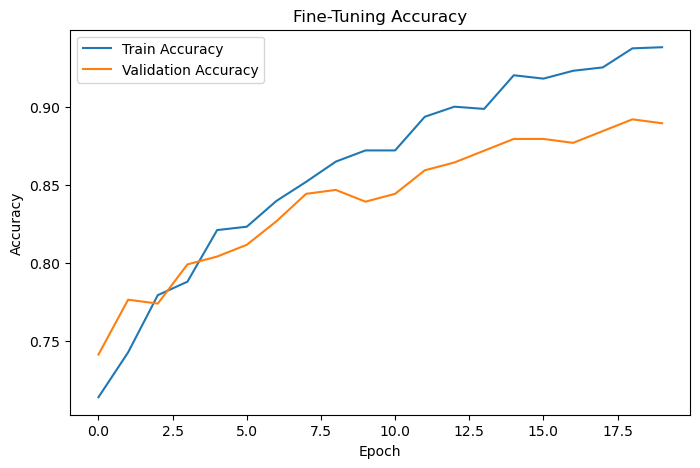

Saved: figures/Fine-Tunning Accuracy_20260325_191637.png


<Figure size 640x480 with 0 Axes>

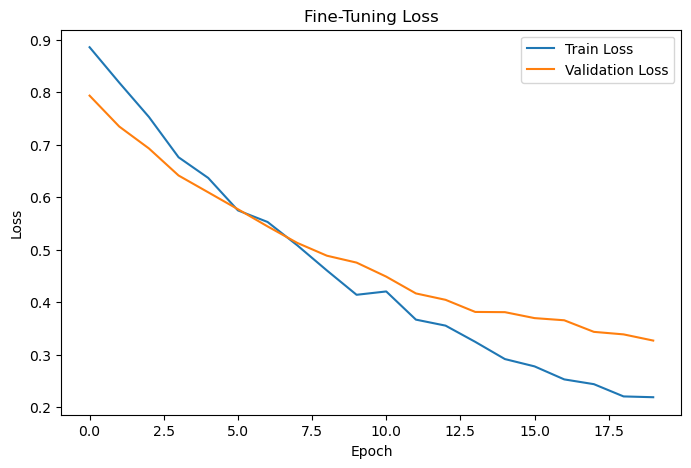

Saved: figures/Fine-Tunning Loss_20260325_191637.png


<Figure size 640x480 with 0 Axes>

In [41]:
plt.figure(figsize=(8,5))
plt.plot(history_fine.history['accuracy'], label='Train Accuracy')
plt.plot(history_fine.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Fine-Tuning Accuracy')
plt.legend()
plt.show()
save_fig("Fine-Tunning Accuracy")

plt.figure(figsize=(8,5))
plt.plot(history_fine.history['loss'], label='Train Loss')
plt.plot(history_fine.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Fine-Tuning Loss')
plt.legend()
plt.show()
save_fig("Fine-Tunning Loss")

## Results and Evaluation

The initial frozen ResNet-50 model achieved approximately 36.0% test accuracy, indicating underfitting due to limited adaptability of pre-trained features.

After unfreezing and fine-tuning the upper layers of the network, performance improved significantly to 70.6% test accuracy.

Further training with early stopping resulted in a final test accuracy of approximately 90.99%, demonstrating that fine-tuning and controlled training significantly enhance model performance.

This progression highlights the effectiveness of transfer learning and iterative optimization in deep learning applications.

7/7 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step


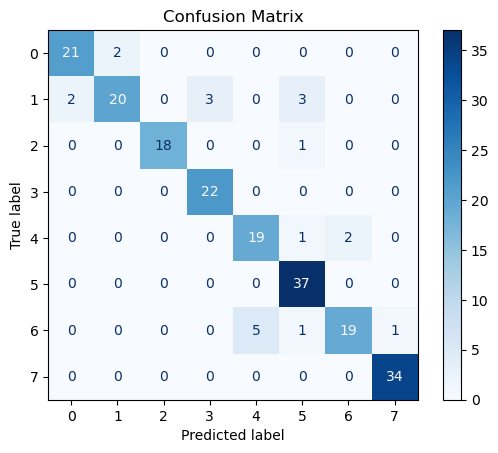

Saved: figures/Confusion Matrix_20260325_191713.png


<Figure size 640x480 with 0 Axes>

In [42]:
y_pred = model.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = test_generator.classes

cm = confusion_matrix(y_true, y_pred_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()
save_fig("Confusion Matrix")

The dataset consists of 2000 images across 8 distracted driving behavior classes.

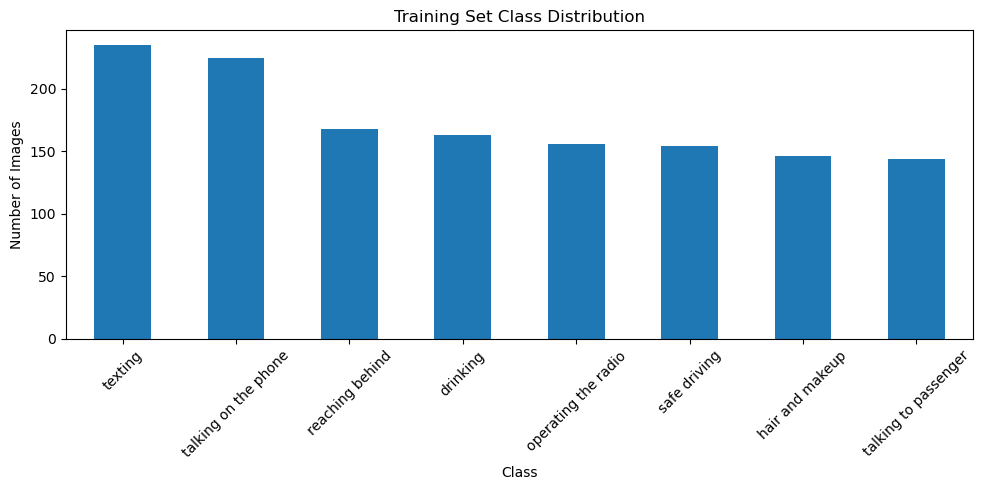

Saved: figures/Training Set Class Distribution_20260325_191731.png


<Figure size 640x480 with 0 Axes>

In [43]:
plt.figure(figsize=(10,5))
train_df["class"].value_counts().plot(kind="bar")
plt.title("Training Set Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
save_fig("Training Set Class Distribution")

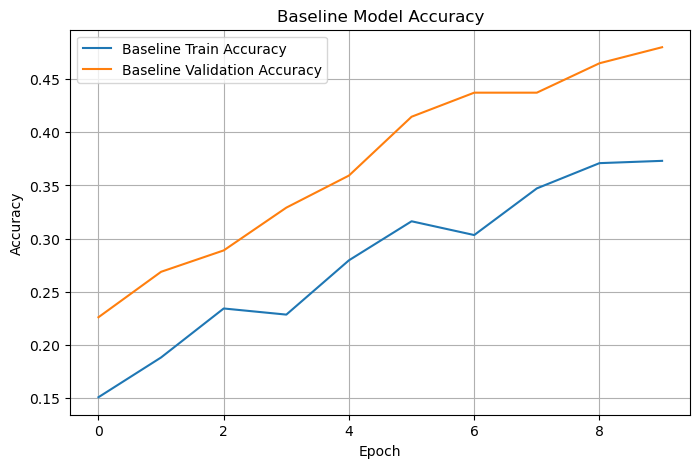

Saved: figures/Baseline Model Accuracy_20260325_191737.png


<Figure size 640x480 with 0 Axes>

In [44]:
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Baseline Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Baseline Validation Accuracy')
plt.title("Baseline Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()
save_fig("Baseline Model Accuracy")

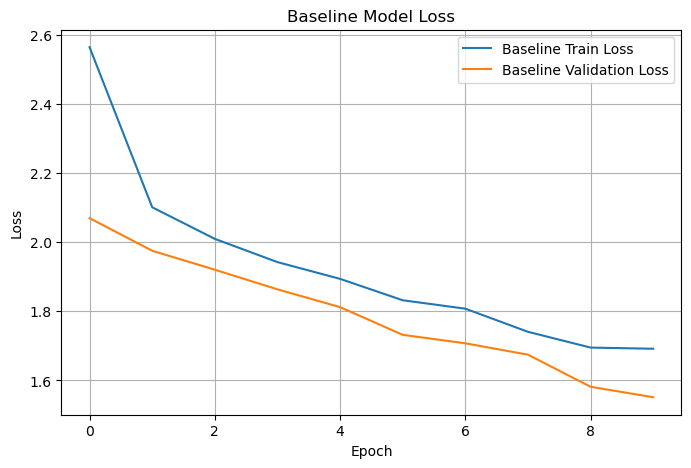

Saved: figures/Baseline Model Loss_20260325_191742.png


<Figure size 640x480 with 0 Axes>

In [45]:
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Baseline Train Loss')
plt.plot(history.history['val_loss'], label='Baseline Validation Loss')
plt.title("Baseline Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()
save_fig("Baseline Model Loss")

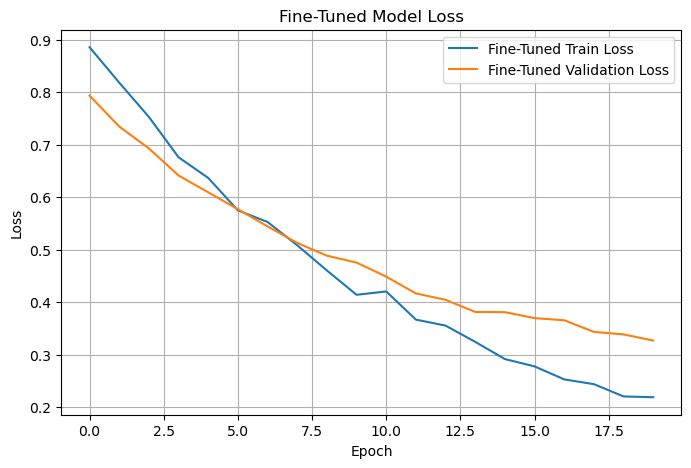

Saved: figures/Fine-Tuned Model Loss_20260325_191746.png


<Figure size 640x480 with 0 Axes>

In [46]:
plt.figure(figsize=(8,5))
plt.plot(history_fine.history['loss'], label='Fine-Tuned Train Loss')
plt.plot(history_fine.history['val_loss'], label='Fine-Tuned Validation Loss')
plt.title("Fine-Tuned Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()
save_fig("Fine-Tuned Model Loss")

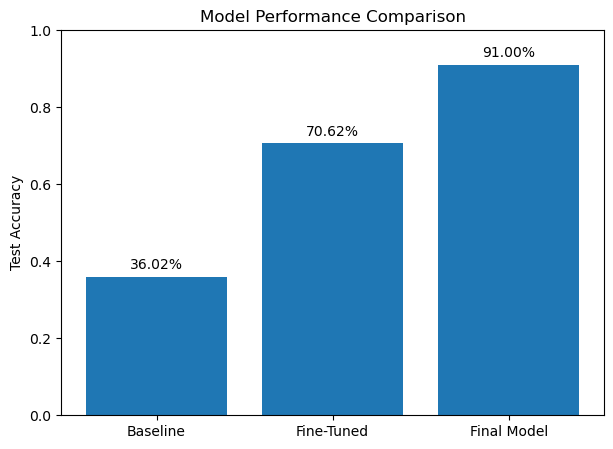

Saved: figures/Model Performance Comparison_20260325_191755.png


<Figure size 640x480 with 0 Axes>

In [47]:
models = ["Baseline", "Fine-Tuned", "Final Model"]
accuracies = [0.3602, 0.7062, 0.90995]

plt.figure(figsize=(7,5))
plt.bar(models, accuracies)
plt.title("Model Performance Comparison")
plt.ylabel("Test Accuracy")
plt.ylim(0, 1.0)

for i, acc in enumerate(accuracies):
    plt.text(i, acc + 0.02, f"{acc:.2%}", ha='center')

plt.show()
save_fig("Model Performance Comparison")

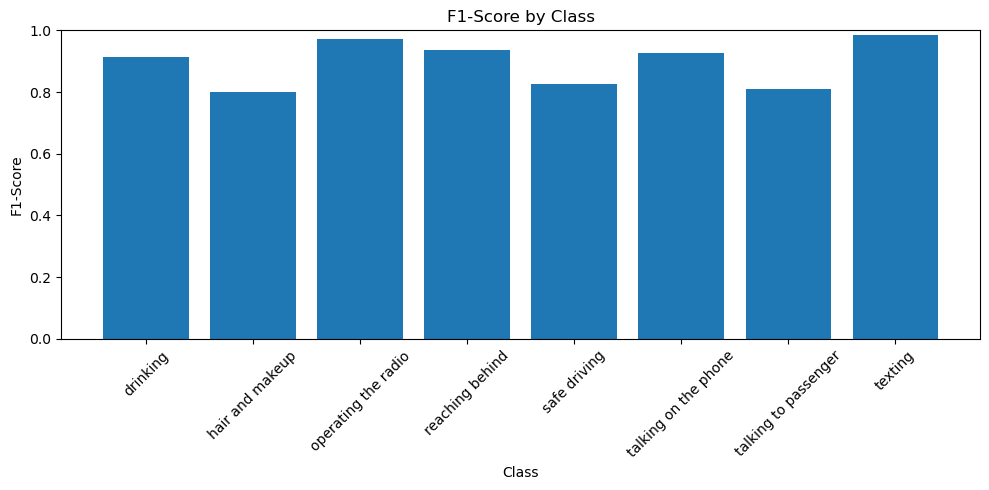

Saved: figures/F1-Score by Class_20260325_191800.png


<Figure size 640x480 with 0 Axes>

In [48]:
report = classification_report(y_true, y_pred_classes, target_names=list(train_generator.class_indices.keys()), output_dict=True)
report_df = pd.DataFrame(report).transpose()

class_report_df = report_df.iloc[:-3, :]  # remove accuracy/macro avg/weighted avg

plt.figure(figsize=(10,5))
plt.bar(class_report_df.index, class_report_df["f1-score"])
plt.title("F1-Score by Class")
plt.xlabel("Class")
plt.ylabel("F1-Score")
plt.xticks(rotation=45)
plt.ylim(0, 1.0)
plt.tight_layout()
plt.show()
save_fig("F1-Score by Class")

## Image Preprocessing and Augmentation Visualization

In this step, we visualize how raw input images are transformed before being used for model training. This helps illustrate the preprocessing pipeline and the role of data augmentation in improving model performance.

### Original Image
The first image represents the **raw input image** as stored in the dataset. These images may vary in size, orientation, and lighting conditions.

### Resized Image
The second image shows the same input after being resized to **224 × 224 pixels**, which is required for compatibility with the ResNet-50 architecture.  
Standardizing image size ensures consistent input dimensions for the neural network.

### Augmented Image
The third image demonstrates the result of **data augmentation**, where transformations such as:
- rotation  
- zooming  
- shifting (horizontal and vertical)  
- horizontal flipping  
- brightness adjustment  

are applied to the original image.

### Purpose of Augmentation

Data augmentation increases the diversity of the training dataset without collecting new data. This helps the model:
- generalize better to unseen images  
- become robust to variations in lighting, orientation, and position  
- reduce overfitting, especially when working with relatively small datasets  

### Summary

By visualizing these transformations, we confirm that the preprocessing pipeline is correctly applied and that the model is exposed to a wider variety of input conditions during training, contributing to improved performance and generalization.

## Image Preprocessing and Augmentation Examples

The following examples show how raw driver images are transformed before model training. Images are first resized to 224×224 pixels to match ResNet-50 input requirements, and then augmentation techniques such as rotation, shifting, zooming, horizontal flipping, and brightness adjustment are applied to improve generalization.

Saved: figures/Original Image_20260325_191912.png
Saved: figures/Resized Image (224x224)_20260325_191912.png


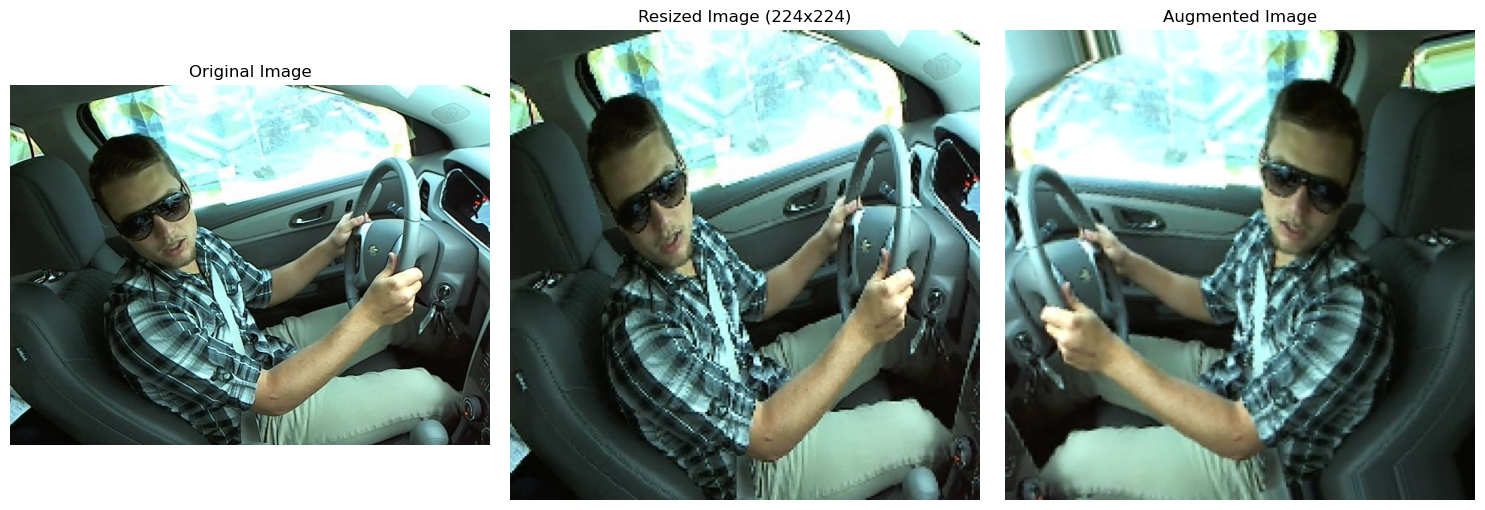

Saved: figures/Augmented Image_20260325_191913.png


<Figure size 640x480 with 0 Axes>

In [49]:
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.preprocessing import image

# Pick one sample image
sample_path = train_df["filepath"].iloc[0]

# Load original image
img = image.load_img(sample_path)
img_array = image.img_to_array(img)

# Load resized image
img_resized = image.load_img(sample_path, target_size=(224, 224))
img_resized_array = image.img_to_array(img_resized)

# Create one augmented version
augment_only = ImageDataGenerator(
    rotation_range=15,
    zoom_range=0.15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2]
)

img_batch = np.expand_dims(img_resized_array, axis=0)
augmented_batch = next(augment_only.flow(img_batch, batch_size=1))
augmented_img = augmented_batch[0].astype("uint8")

# Plot
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(img_array.astype("uint8"))
plt.title("Original Image")
plt.axis("off")
save_fig("Original Image")

plt.subplot(1,3,2)
plt.imshow(img_resized_array.astype("uint8"))
plt.title("Resized Image (224x224)")
plt.axis("off")
save_fig("Resized Image (224x224)")

plt.subplot(1,3,3)
plt.imshow(augmented_img)
plt.title("Augmented Image")
plt.axis("off")

plt.tight_layout()
plt.show()
save_fig("Augmented Image")

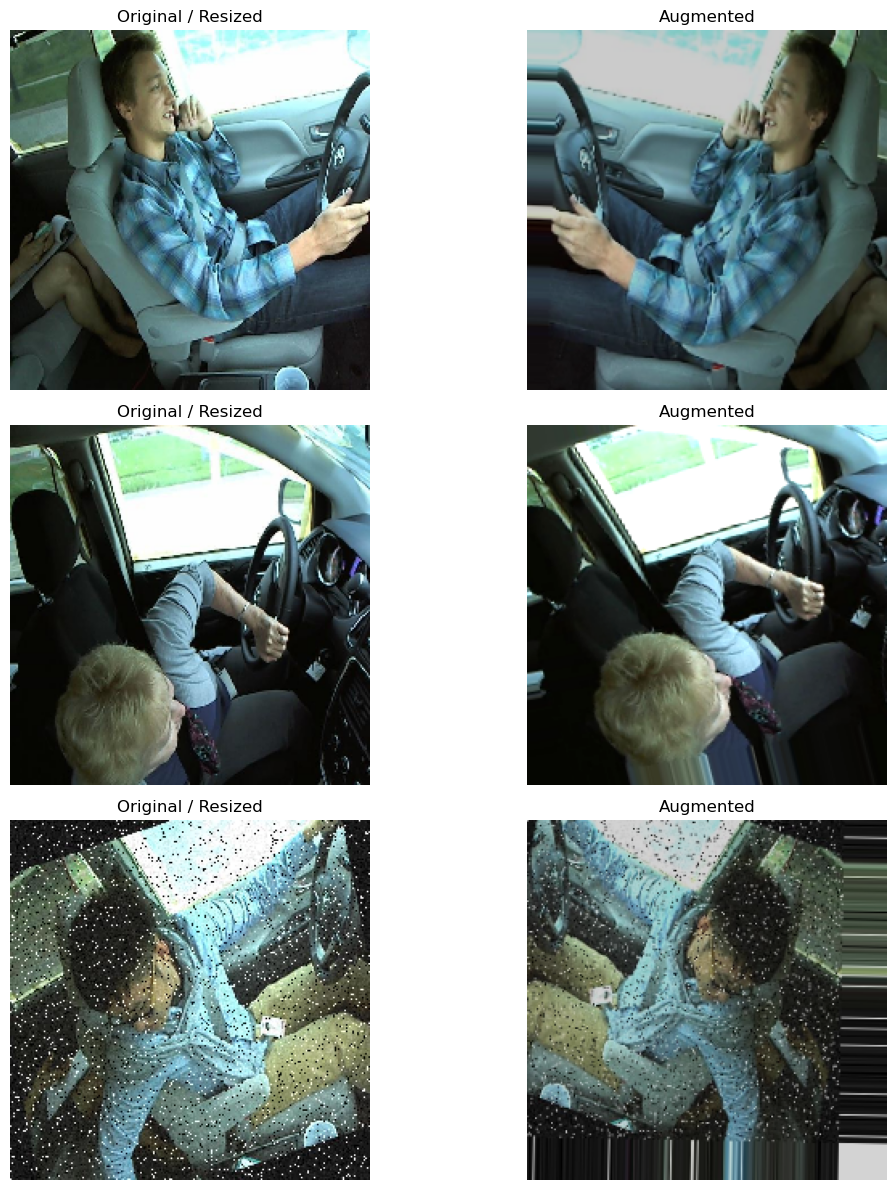

In [52]:
sample_paths = train_df["filepath"].sample(3, random_state=42).tolist()

augment_only = ImageDataGenerator(
    rotation_range=15,
    zoom_range=0.15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2]
)

plt.figure(figsize=(12, 12))

for i, sample_path in enumerate(sample_paths):
    img_resized = image.load_img(sample_path, target_size=(224, 224))
    img_array = image.img_to_array(img_resized)

    img_batch = np.expand_dims(img_array, axis=0)
    augmented_batch = next(augment_only.flow(img_batch, batch_size=1))
    augmented_img = augmented_batch[0].astype("uint8")

    plt.subplot(3, 2, 2*i + 1)
    plt.imshow(img_array.astype("uint8"))
    plt.title("Original / Resized")
    plt.axis("off")

    plt.subplot(3, 2, 2*i + 2)
    plt.imshow(augmented_img)
    plt.title("Augmented")
    plt.axis("off")

plt.tight_layout()
plt.show()


## Additional Augmentation Examples

To further illustrate the effect of data augmentation, multiple sample images are transformed using random augmentation techniques. This demonstrates how different variations are generated from the same data, helping the model generalize better across diverse input conditions.

In [53]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt

def get_gradcam_heatmap(img_array, model, last_conv_layer_name):
    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        class_idx = tf.argmax(predictions[0])
        loss = predictions[:, class_idx]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # Convert to numpy if needed
    heatmap = heatmap.numpy() if hasattr(heatmap, "numpy") else heatmap

    # Normalize safely
    heatmap = np.maximum(heatmap, 0)
    heatmap = heatmap / (np.max(heatmap) + 1e-8)

    return heatmap

## Model Interpretability with Grad-CAM

To better understand how the model makes predictions, Gradient-weighted Class Activation Mapping (Grad-CAM) is used to visualize the regions of an image that most influence the model’s decision.

### How It Works

Grad-CAM computes the gradient of the predicted class score with respect to the feature maps of the last convolutional layer. These gradients are then used to produce a heatmap that highlights important regions in the image.

### Purpose

This technique helps to:
- Identify which parts of the image the model is focusing on  
- Validate whether the model is learning meaningful features  
- Improve interpretability of deep learning predictions  

### Interpretation

The resulting heatmap emphasizes areas such as:
- the driver’s hands  
- objects like phones or drinks  
- facial orientation or posture  

These regions are critical for distinguishing between different distracted driving behaviors.

### Summary

By incorporating Grad-CAM, the model becomes more transparent, allowing us to verify that predictions are based on relevant visual cues rather than irrelevant background features.

## Misclassification Analysis

To better understand the limitations of the model, we analyze cases where the model makes incorrect predictions on the test dataset.

### Approach

- Identify misclassified samples by comparing predicted labels with true labels  
- Select a subset of misclassified images  
- Visualize each image along with:
  - **True label**
  - **Predicted label**
  - **Prediction confidence**

### Purpose

This analysis helps to:
- Identify patterns in model errors  
- Understand which classes are frequently confused  
- Reveal challenging or ambiguous cases in the dataset  

### Observations

Misclassifications often occur when:
- Different classes share similar visual features (e.g., texting vs. talking on the phone)  
- The object of interest is partially occluded or unclear  
- Lighting conditions or image quality vary  

### Importance

Analyzing misclassified examples is critical for improving model performance. It provides insights into:
- Potential dataset limitations  
- Areas where additional data or augmentation may help  
- Opportunities for further model refinement  

### Summary

This step highlights that while the model achieves high overall accuracy, some errors remain due to the complexity and similarity of distracted driving behaviors. Understanding these errors is essential for building more robust and reliable systems.

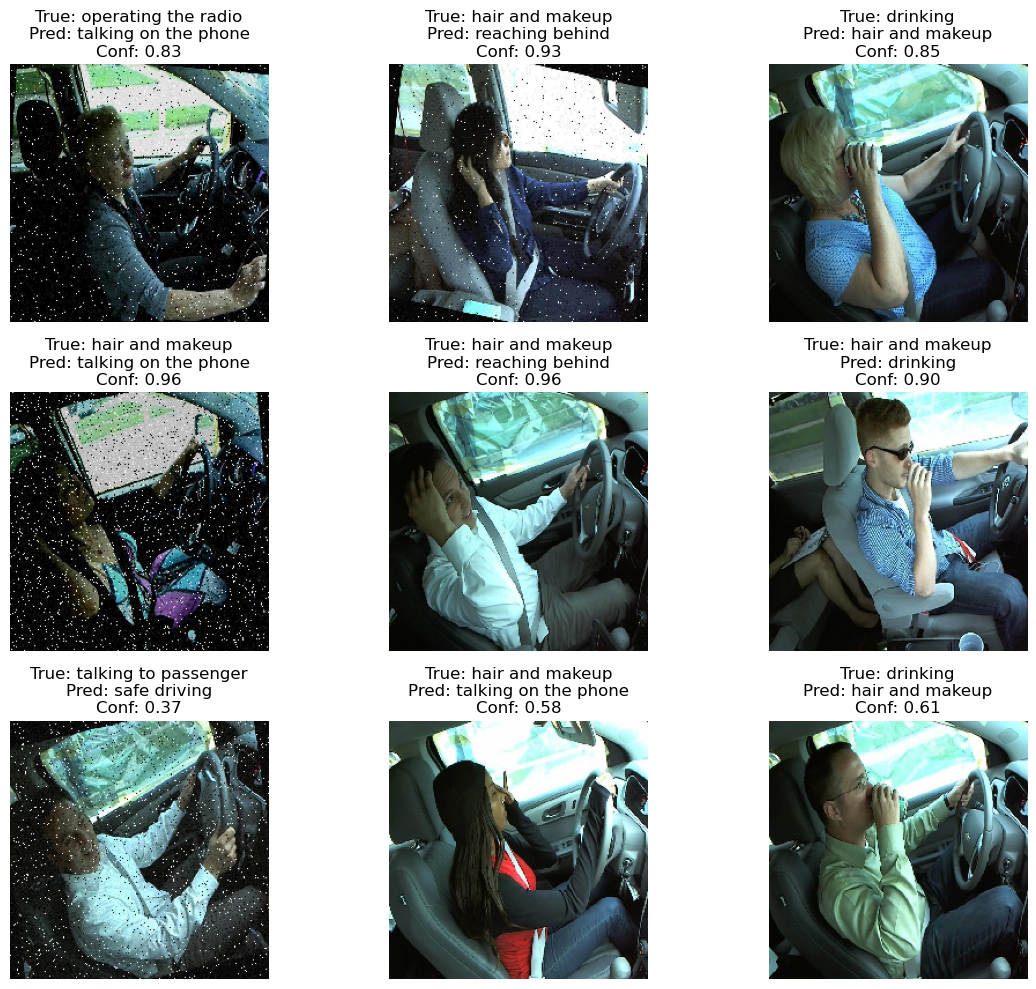

Saved: figures/Predictions_20260325_192155.png


<Figure size 640x480 with 0 Axes>

In [54]:
from tensorflow.keras.preprocessing import image

class_names = list(train_generator.class_indices.keys())
misclassified_idx = np.where(y_pred_classes != y_true)[0]

plt.figure(figsize=(12, 10))

for i, idx in enumerate(misclassified_idx[:9]):
    img_path = test_df.iloc[idx]["filepath"]
    true_label = class_names[y_true[idx]]
    pred_label = class_names[y_pred_classes[idx]]
    confidence = y_pred[idx][y_pred_classes[idx]]

    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img).astype("uint8")

    plt.subplot(3, 3, i + 1)
    plt.imshow(img_array)
    plt.title(f"True: {true_label}\nPred: {pred_label}\nConf: {confidence:.2f}")
    plt.axis("off")

plt.tight_layout()
plt.show()
save_fig("Predictions")

Most errors occur between behavior classes with similar visual patterns, such as texting and talking on the phone, or talking to passenger and reaching behind.

In [55]:
ModelCheckpoint("best_model.h5", save_best_only=True)

In [56]:
ModelCheckpoint("best_model.h5", save_best_only=True)

In [58]:
from tensorflow.keras.models import load_model

model = load_model("best_model.h5")